# Major Project: Seasonal Agriculture Performance Analysis

### VOIS AICTE  2026–2027

## 1. Introduction to Dataset

The dataset represents agricultural activities carried out across different seasons, geographical areas and farming conditions. It contains information related to farming practices, environmental conditions, crop production, resource usage and economic performance.

This notebook analyzes the available agricultural data to understand how agricultural performance changes across seasons and to identify meaningful patterns, trends, relationships and variations.

## Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and market conditions. As a result, agricultural performance may differ from one season to another.

The problem is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.

## Objectives

1. Explore and understand the dataset.
2. Clean and prepare the data for analysis.
3. Examine how agricultural performance varies across seasons.
4. Identify important seasonal patterns and trends.
5. Investigate relationships between seasonal conditions and agricultural outcomes.
6. Compare relevant groups within different seasons.
7. Identify significant differences or unusual patterns.
8. Apply appropriate statistical and visualization techniques.
9. Interpret findings based on evidence from the dataset.
10. Develop meaningful conclusions and data-driven recommendations.

## Expected Outcomes

- Understand seasonal agricultural data.
- Perform appropriate data cleaning and preparation.
- Identify important seasonal patterns.
- Compare agricultural performance across seasons.
- Discover relationships and variations in the data.
- Interpret analytical findings correctly.
- Identify significant observations and evidence-based insights.
- Provide appropriate recommendations based on the findings.
- Document the complete analysis in a Jupyter Notebook.


## 2. Analytical Questions

The project brief asks students to develop specific questions after exploring the dataset. The following questions are used in this notebook:

1. How does agricultural performance vary across seasons?
2. What major seasonal patterns can be observed?
3. Which characteristics change between seasons?
4. What differences exist between agricultural activities in different seasons?
5. Are there noticeable variations in resource usage across seasons?
6. Are there relationships between seasonal environmental conditions and agricultural performance?
7. How do economic outcomes vary across seasons?
8. Are seasonal patterns consistent across different regions or categories?
9. Are there unusual or unexpected seasonal patterns?
10. What insights and recommendations can reasonably be derived from the available data?


## 3. Import Libraries


In [40]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 4. Load and Explore the Dataset

The notebook first locates the supplied CSV file, loads it, and inspects its structure. No values are fabricated or manually entered into the analysis.


In [41]:
# Expected project dataset name.
expected_file = "seasonal_agriculture_performance_dataset.csv"

# Look in the notebook's current directory first.
csv_candidates = glob.glob("*.csv")

if os.path.exists(expected_file):
    data_path = expected_file
elif len(csv_candidates) == 1:
    data_path = csv_candidates[0]
else:
    raise FileNotFoundError(
        "Dataset CSV not found. Place 'seasonal_agriculture_performance_dataset.csv' "
        "in the same folder as this notebook and run again."
    )

df = pd.read_csv(data_path)

print(f"Dataset file: {data_path}")
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
display(df.head())


Dataset file: seasonal_agriculture_performance_dataset.csv
Dataset shape: 4000 rows x 28 columns


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [42]:
print("Data types and non-null counts:")
df.info()


Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha  

In [43]:
print("Descriptive statistics for numeric variables:")
display(df.describe(include="all").T)


Descriptive statistics for numeric variables:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF13984,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,4000.0,NaN,NaN,NaN,7.888265,4.223764,0.5,4.26,7.895,11.65,15.0
Rainfall_mm,3952.0,NaN,NaN,NaN,601.152657,288.925025,80.0,370.2,582.0,834.95,1395.2
Avg_Temperature_C,4000.0,NaN,NaN,NaN,26.8189,3.81818,16.2,23.9,26.9,29.6,39.7
Humidity_pct,4000.0,NaN,NaN,NaN,63.2105,11.960834,25.0,54.775,63.0,71.9,95.0
Sunlight_Hours_Day,4000.0,NaN,NaN,NaN,7.32305,1.121186,3.5,6.6,7.3,8.1,11.0


In [44]:
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).head(20))



--- Farm_ID ---
Farm_ID
SF13984    1
SF13983    1
SF13982    1
SF13981    1
SF13980    1
SF13979    1
SF13978    1
SF13977    1
SF13976    1
SF13975    1
SF13974    1
SF13973    1
SF13972    1
SF13971    1
SF13970    1
SF13969    1
SF10032    1
SF10031    1
SF10030    1
SF10029    1
Name: count, dtype: int64

--- State ---
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

--- District ---
District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Raichur     386
Nashik      371
Name: count, dtype: int64

--- Crop ---
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

--- Season ---
Season
Kharif    1779
Rabi      1627
Zaid       594
Name

## 5. Data Cleaning and Preparation

### 5.1 Column and Data-Type Checks


In [45]:
print("Column names:")
print(df.columns.tolist())

print("\nMissing values by column:")
missing = df.isna().sum()
display(missing[missing > 0].sort_values(ascending=False))

print("\nDuplicate rows:", df.duplicated().sum())


Column names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Missing values by column:


,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32



Duplicate rows: 0


In [46]:
# Convert numeric-looking columns to numeric where possible.
# Existing numeric columns remain unchanged.
for col in df.columns:
    if df[col].dtype == "object":
        converted = pd.to_numeric(df[col], errors="coerce")
        if converted.notna().mean() > 0.95:
            df[col] = converted

print("Data types after basic preparation:")
display(df.dtypes.to_frame("dtype"))


Data types after basic preparation:


,dtype
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


### 5.2 Missing Values

Missing values are handled only where appropriate. For the known seasonal numeric measures in this project, missing observations are imputed using the median within the same season. This preserves the seasonal context better than replacing values with one global median.


In [47]:
season_col = "Season"
season_numeric_impute = [
    c for c in ["Rainfall_mm", "Soil_Moisture_pct", "Yield_Tonnes_Ha"]
    if c in df.columns
]

before_missing = int(df.isna().sum().sum())

if season_col in df.columns:
    for col in season_numeric_impute:
        df[col] = df.groupby(season_col, observed=True)[col].transform(
            lambda x: x.fillna(x.median())
        )

print("Missing cells before imputation:", before_missing)
print("Missing cells after seasonal imputation:", int(df.isna().sum().sum()))

remaining = df.isna().sum()
display(remaining[remaining > 0].sort_values(ascending=False))


Missing cells before imputation: 120
Missing cells after seasonal imputation: 0


,0


### 5.3 Duplicate and Sanity Checks


In [48]:
if "Farm_ID" in df.columns:
    print("Duplicate Farm_ID values:", df["Farm_ID"].duplicated().sum())

print("Fully duplicated rows:", df.duplicated().sum())


Duplicate Farm_ID values: 0
Fully duplicated rows: 0


In [49]:
numeric_range_cols = [
    "Farm_Area_Hectares", "Rainfall_mm", "Avg_Temperature_C",
    "Humidity_pct", "Soil_pH", "Yield_Tonnes_Ha", "Production_Tonnes",
    "Market_Price_INR_Tonne", "Water_Used_m3", "Disease_Pest_Risk_pct"
]
numeric_range_cols = [c for c in numeric_range_cols if c in df.columns]

if numeric_range_cols:
    print("Observed minimum and maximum values:")
    display(df[numeric_range_cols].agg(["min", "max"]).T)


Observed minimum and maximum values:


,min,max
Farm_Area_Hectares,0.50,15.00
Rainfall_mm,80.00,1395.20
Avg_Temperature_C,16.20,39.70
Humidity_pct,25.00,95.00
Soil_pH,5.20,8.40
Yield_Tonnes_Ha,0.30,101.44
Production_Tonnes,0.15,1424.40
Market_Price_INR_Tonne,2594.00,131240.00
Water_Used_m3,128.00,40902.00
Disease_Pest_Risk_pct,5.00,88.90


In [50]:
def iqr_outlier_count(series):
    s = series.dropna()
    if len(s) == 0:
        return 0
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return int(((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum())

for col in ["Yield_Tonnes_Ha", "Profit_INR", "Water_Used_m3"]:
    if col in df.columns:
        print(f"{col}: {iqr_outlier_count(df[col])} IQR statistical outliers")
print("\nIQR outliers are flagged for investigation, not automatically deleted.")


Yield_Tonnes_Ha: 302 IQR statistical outliers
Profit_INR: 404 IQR statistical outliers
Water_Used_m3: 276 IQR statistical outliers

IQR outliers are flagged for investigation, not automatically deleted.


### 5.4 Feature Engineering


In [51]:
required_for_features = [
    "Profit_INR", "Revenue_INR", "Total_Cost_INR", "Farm_Area_Hectares",
    "Nitrogen_kg_ha", "Phosphorus_kg_ha", "Potassium_kg_ha"
]

missing_features = [c for c in required_for_features if c not in df.columns]
if missing_features:
    print("Feature-engineering columns not available:", missing_features)
else:
    df["Profit_Margin_pct"] = np.where(
        df["Revenue_INR"] != 0,
        df["Profit_INR"] / df["Revenue_INR"] * 100,
        np.nan
    )
    df["Cost_per_Hectare"] = np.where(
        df["Farm_Area_Hectares"] != 0,
        df["Total_Cost_INR"] / df["Farm_Area_Hectares"],
        np.nan
    )
    df["Revenue_per_Hectare"] = np.where(
        df["Farm_Area_Hectares"] != 0,
        df["Revenue_INR"] / df["Farm_Area_Hectares"],
        np.nan
    )
    df["Is_Profitable"] = df["Profit_INR"] > 0
    df["NPK_Total_kg_ha"] = (
        df["Nitrogen_kg_ha"] +
        df["Phosphorus_kg_ha"] +
        df["Potassium_kg_ha"]
    )

display(df.head())


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Profit_Margin_pct,Cost_per_Hectare,Revenue_per_Hectare,Is_Profitable,NPK_Total_kg_ha
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3,-38.468030,80494.339623,58132.075472,False,228.1
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9,-1118.660429,75398.315467,6186.983155,False,239.3
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7,-65.494104,64858.024691,39190.534979,False,287.9
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6,-47.675600,65876.444444,44608.888889,False,309.7
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3,-74.559288,80275.296912,45987.410926,False,314.5


## 6. Seasonal Distribution Overview


In [52]:
if "Season" not in df.columns:
    raise KeyError("The dataset must contain a 'Season' column.")

season_order = [s for s in ["Kharif", "Rabi", "Zaid"] if s in df["Season"].dropna().unique()]
other_seasons = [s for s in df["Season"].dropna().unique() if s not in season_order]
season_order += other_seasons
df["Season"] = pd.Categorical(df["Season"], categories=season_order, ordered=True)

print("Records by season:")
display(df["Season"].value_counts().reindex(season_order))


Records by season:


,count
Season,
Kharif,1779
Rabi,1627
Zaid,594


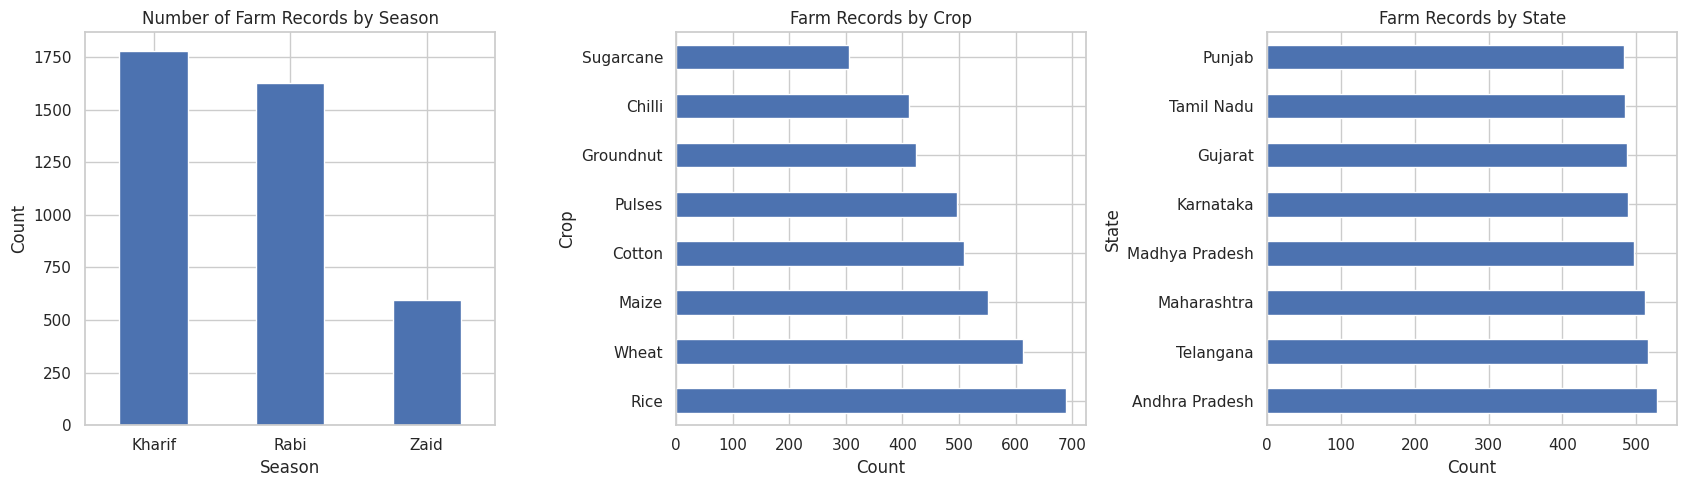

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

df["Season"].value_counts().reindex(season_order).plot(kind="bar", ax=axes[0])
axes[0].set_title("Number of Farm Records by Season")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

if "Crop" in df.columns:
    df["Crop"].value_counts().plot(kind="barh", ax=axes[1])
    axes[1].set_title("Farm Records by Crop")
    axes[1].set_xlabel("Count")
else:
    axes[1].axis("off")

if "State" in df.columns:
    df["State"].value_counts().plot(kind="barh", ax=axes[2])
    axes[2].set_title("Farm Records by State")
    axes[2].set_xlabel("Count")
else:
    axes[2].axis("off")

plt.tight_layout()
plt.show()


In [54]:
if "Crop" in df.columns:
    print("Crop × Season distribution:")
    display(pd.crosstab(df["Crop"], df["Season"]))


Crop × Season distribution:


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,185,163,64
Cotton,215,201,92
Groundnut,193,177,54
Maize,234,233,84
Pulses,221,213,62
Rice,314,274,102
Sugarcane,125,129,51
Wheat,292,237,85


## 7. Seasonal Agricultural Performance

### Q1 — How does agricultural performance vary across seasons?


In [55]:
performance_cols = [c for c in [
    "Yield_Tonnes_Ha", "Production_Tonnes", "Revenue_INR",
    "Total_Cost_INR", "Profit_INR", "Profit_Margin_pct"
] if c in df.columns]

season_performance = df.groupby("Season", observed=True)[performance_cols].agg(["mean", "median"]).round(2)
display(season_performance)


Yield_Tonnes_Ha        Production_Tonnes        Revenue_INR           Total_Cost_INR           Profit_INR          Profit_Margin_pct       
                  mean median              mean median        mean    median           mean    median       mean   median              mean median
Season                                                                                                                                            
Kharif            5.63   1.95             46.31  13.24   710719.06  520196.0      531804.41  524840.0  178914.65  38808.0            -38.64  11.09
Rabi              5.04   1.66             41.49  11.08   601526.05  438156.0      513836.58  506733.0   87689.47  -3187.0            -44.27  -1.34
Zaid              4.64   1.45             38.89   9.97   519171.90  373700.5      543976.73  534833.0  -24804.82 -62144.0            -69.35 -24.59

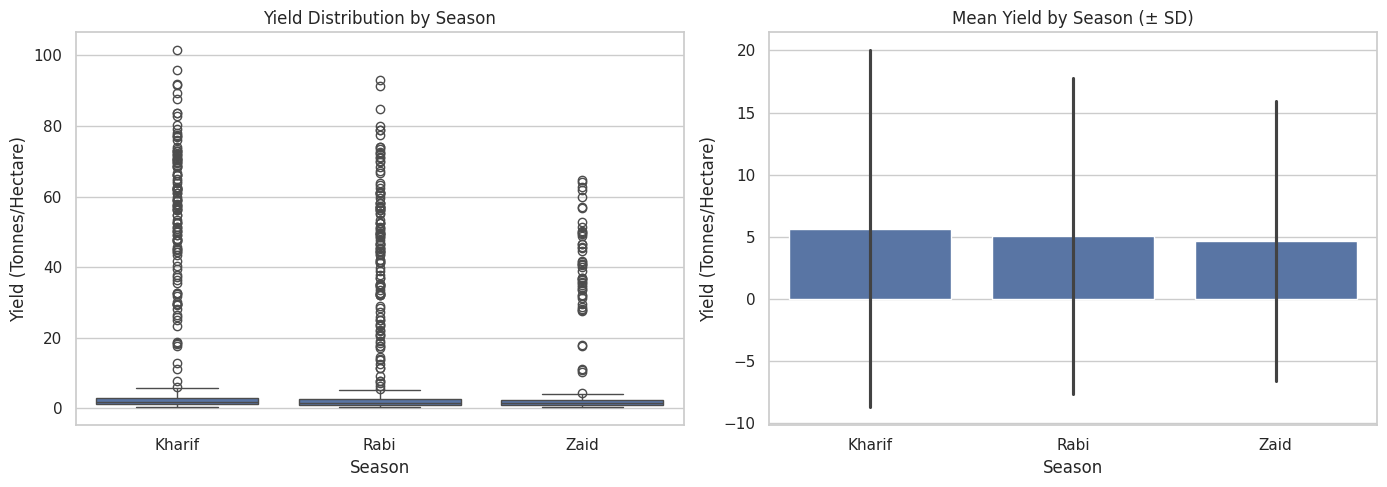

In [56]:
if "Yield_Tonnes_Ha" in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha", order=season_order, ax=axes[0])
    axes[0].set_title("Yield Distribution by Season")
    axes[0].set_ylabel("Yield (Tonnes/Hectare)")

    sns.barplot(
        data=df, x="Season", y="Yield_Tonnes_Ha",
        order=season_order, estimator=np.mean, errorbar="sd", ax=axes[1]
    )
    axes[1].set_title("Mean Yield by Season (± SD)")
    axes[1].set_ylabel("Yield (Tonnes/Hectare)")

    plt.tight_layout()
    plt.show()


### Statistical Test — Seasonal Difference in Yield


In [57]:
if "Yield_Tonnes_Ha" in df.columns and len(season_order) >= 2:
    groups = [
        df.loc[df["Season"] == s, "Yield_Tonnes_Ha"].dropna()
        for s in season_order
    ]
    groups = [g for g in groups if len(g) > 0]

    if len(groups) >= 2:
        f_stat, p_val = stats.f_oneway(*groups)
        print(f"One-way ANOVA: F = {f_stat:.3f}, p = {p_val:.6f}")
        print(
            "Interpretation:",
            "seasonal mean yield differences are statistically significant (p < 0.05)."
            if p_val < 0.05
            else "no statistically significant difference in mean yield was detected (p >= 0.05)."
        )


One-way ANOVA: F = 1.554, p = 0.211563
Interpretation: no statistically significant difference in mean yield was detected (p >= 0.05).


## 8. Economic Outcomes Across Seasons

### Q2 — How do economic outcomes vary across seasons?


In [58]:
econ_cols = [c for c in [
    "Revenue_INR", "Total_Cost_INR", "Profit_INR", "Profit_Margin_pct"
] if c in df.columns]

if econ_cols:
    econ_summary = df.groupby("Season", observed=True)[econ_cols].mean().round(2)
    display(econ_summary)

if "Is_Profitable" in df.columns:
    profitable_pct = (
        df.groupby("Season", observed=True)["Is_Profitable"].mean()
        .reindex(season_order) * 100
    )
    print("% of profitable farms by season:")
    display(profitable_pct.round(2))


,Revenue_INR,Total_Cost_INR,Profit_INR,Profit_Margin_pct
Season,,,,
Kharif,710719.06,531804.41,178914.65,-38.64
Rabi,601526.05,513836.58,87689.47,-44.27
Zaid,519171.90,543976.73,-24804.82,-69.35


% of profitable farms by season:


,Is_Profitable
Season,
Kharif,57.79
Rabi,48.86
Zaid,35.52


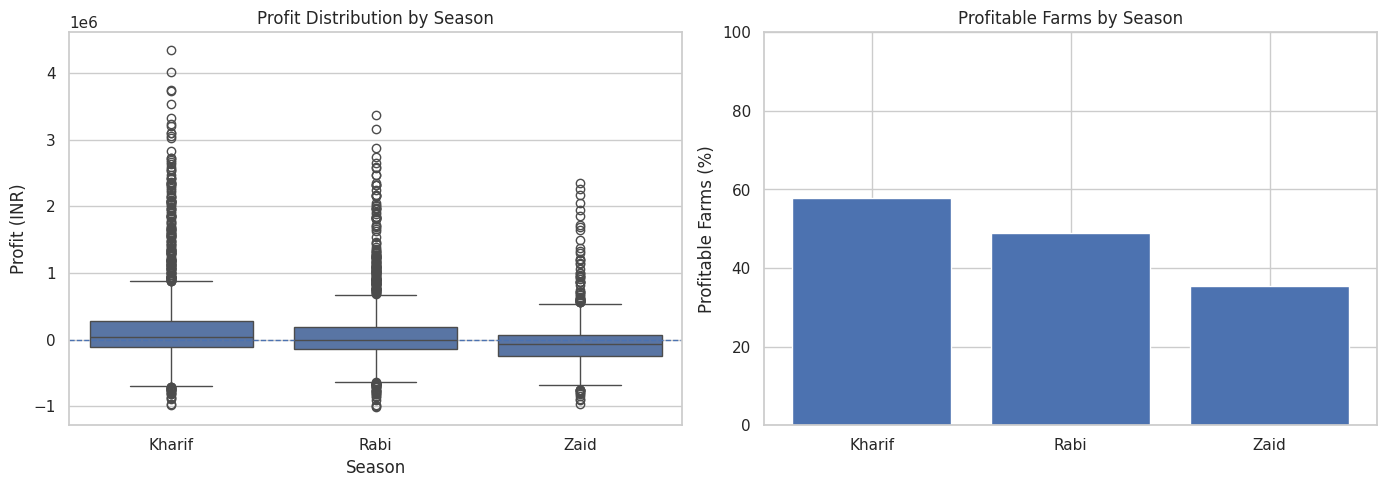

In [59]:
if "Profit_INR" in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.boxplot(data=df, x="Season", y="Profit_INR", order=season_order, ax=axes[0])
    axes[0].axhline(0, linestyle="--", linewidth=1)
    axes[0].set_title("Profit Distribution by Season")
    axes[0].set_ylabel("Profit (INR)")

    if "Is_Profitable" in df.columns:
        pct = df.groupby("Season", observed=True)["Is_Profitable"].mean().reindex(season_order) * 100
        axes[1].bar(pct.index.astype(str), pct.values)
        axes[1].set_ylim(0, 100)
        axes[1].set_title("Profitable Farms by Season")
        axes[1].set_ylabel("Profitable Farms (%)")
    else:
        axes[1].axis("off")

    plt.tight_layout()
    plt.show()


In [60]:
if "Profit_INR" in df.columns and len(season_order) >= 2:
    groups = [df.loc[df["Season"] == s, "Profit_INR"].dropna() for s in season_order]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) >= 2:
        f, p = stats.f_oneway(*groups)
        print(f"One-way ANOVA on Profit: F = {f:.3f}, p = {p:.6f}")


One-way ANOVA on Profit: F = 34.292, p = 0.000000


## 9. Seasonal Environmental Conditions

### Q3 — Which environmental characteristics change between seasons?


In [61]:
env_cols = [c for c in [
    "Rainfall_mm", "Avg_Temperature_C", "Humidity_pct",
    "Sunlight_Hours_Day", "Soil_Moisture_pct"
] if c in df.columns]

if env_cols:
    env_summary = df.groupby("Season", observed=True)[env_cols].mean().round(2)
    display(env_summary)


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,852.11,28.45,71.81,6.79,31.20
Rabi,435.94,23.49,57.89,7.59,24.05
Zaid,299.12,31.04,52.01,8.18,19.17


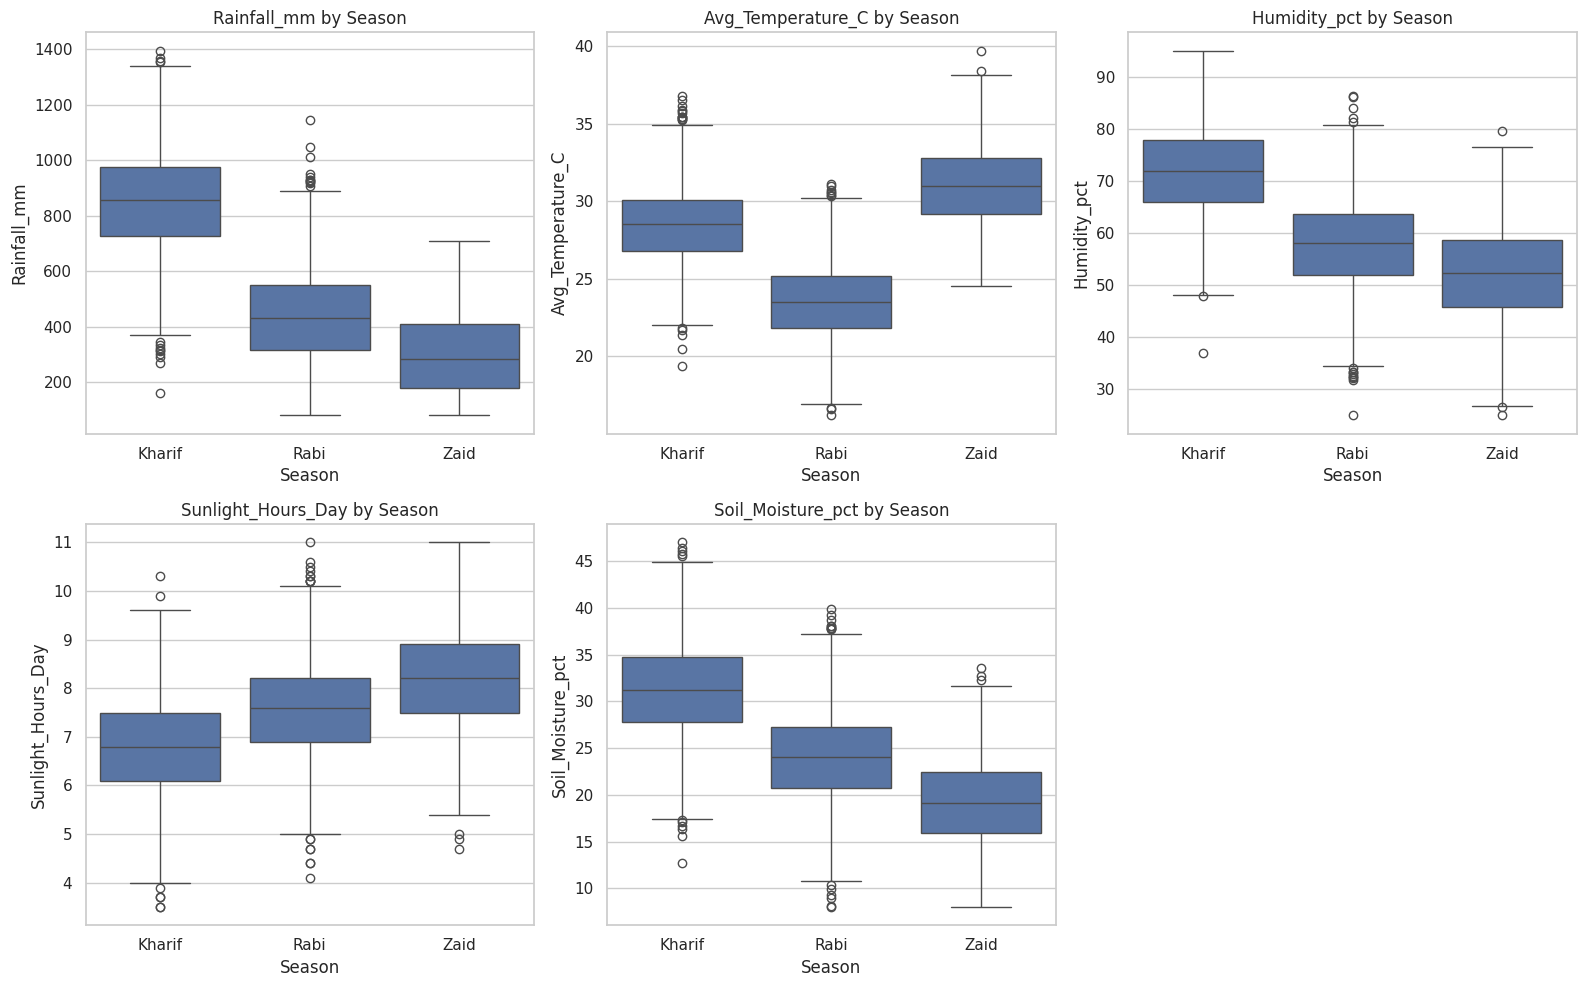

In [62]:
if env_cols:
    n = len(env_cols)
    rows = int(np.ceil(n / 3))
    fig, axes = plt.subplots(rows, 3, figsize=(16, 5 * rows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(env_cols):
        sns.boxplot(data=df, x="Season", y=col, order=season_order, ax=axes[i])
        axes[i].set_title(f"{col} by Season")

    for j in range(n, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


## 10. Resource Usage Across Seasons

### Q4 — Are there noticeable variations in resource usage across seasons?


In [63]:
resource_cols = [c for c in [
    "Water_Used_m3", "Water_Efficiency_t_per_1000m3",
    "Fertilizer_kg_ha", "Pesticide_Litre_ha", "NPK_Total_kg_ha"
] if c in df.columns]

if resource_cols:
    resource_summary = df.groupby("Season", observed=True)[resource_cols].mean().round(2)
    display(resource_summary)


,Water_Used_m3,Water_Efficiency_t_per_1000m3,Fertilizer_kg_ha,Pesticide_Litre_ha,NPK_Total_kg_ha
Season,,,,,
Kharif,6102.20,5.89,187.08,5.08,283.42
Rabi,5846.99,5.19,185.41,5.02,281.64
Zaid,6419.89,4.41,184.64,5.17,284.07


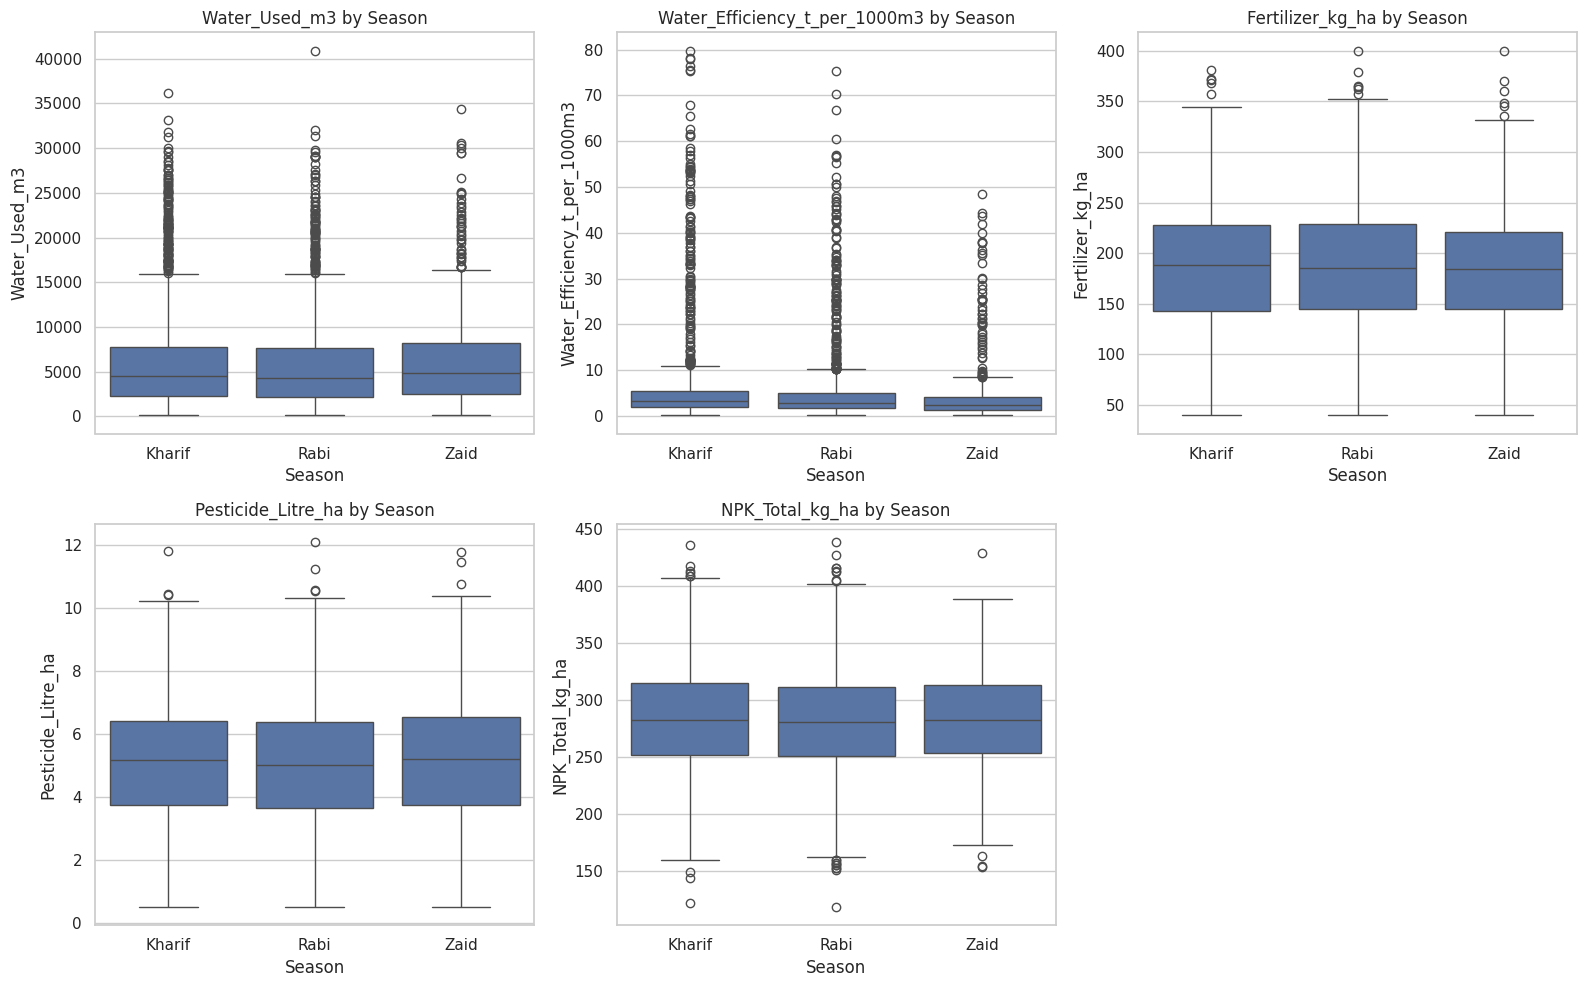

In [64]:
if resource_cols:
    n = len(resource_cols)
    rows = int(np.ceil(n / 3))
    fig, axes = plt.subplots(rows, 3, figsize=(16, 5 * rows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(resource_cols):
        sns.boxplot(data=df, x="Season", y=col, order=season_order, ax=axes[i])
        axes[i].set_title(f"{col} by Season")

    for j in range(n, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


Irrigation method share (%) by season:


Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,22.77,33.16,26.03,18.04
Rabi,22.74,32.33,26.92,18.01
Zaid,23.57,32.66,23.57,20.20


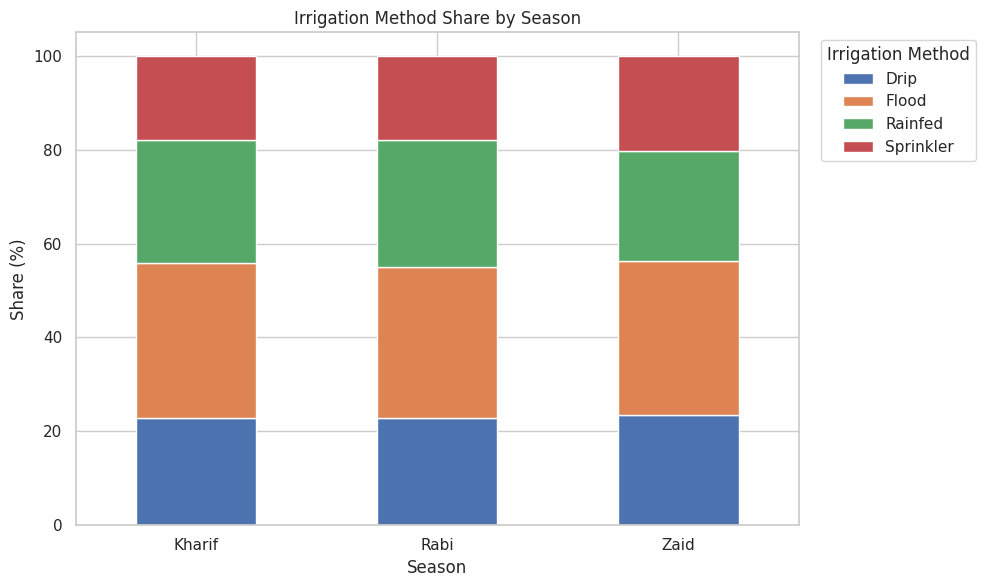

In [65]:
if {"Season", "Irrigation_Method"}.issubset(df.columns):
    irrigation_share = (
        pd.crosstab(df["Season"], df["Irrigation_Method"], normalize="index") * 100
    ).reindex(season_order).round(2)

    print("Irrigation method share (%) by season:")
    display(irrigation_share)

    irrigation_share.plot(kind="bar", stacked=True, figsize=(10, 6))
    plt.title("Irrigation Method Share by Season")
    plt.xlabel("Season")
    plt.ylabel("Share (%)")
    plt.xticks(rotation=0)
    plt.legend(title="Irrigation Method", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


## 11. Relationships Between Environmental Conditions and Performance

### Q5 — Are there relationships between seasonal environmental conditions and agricultural performance?


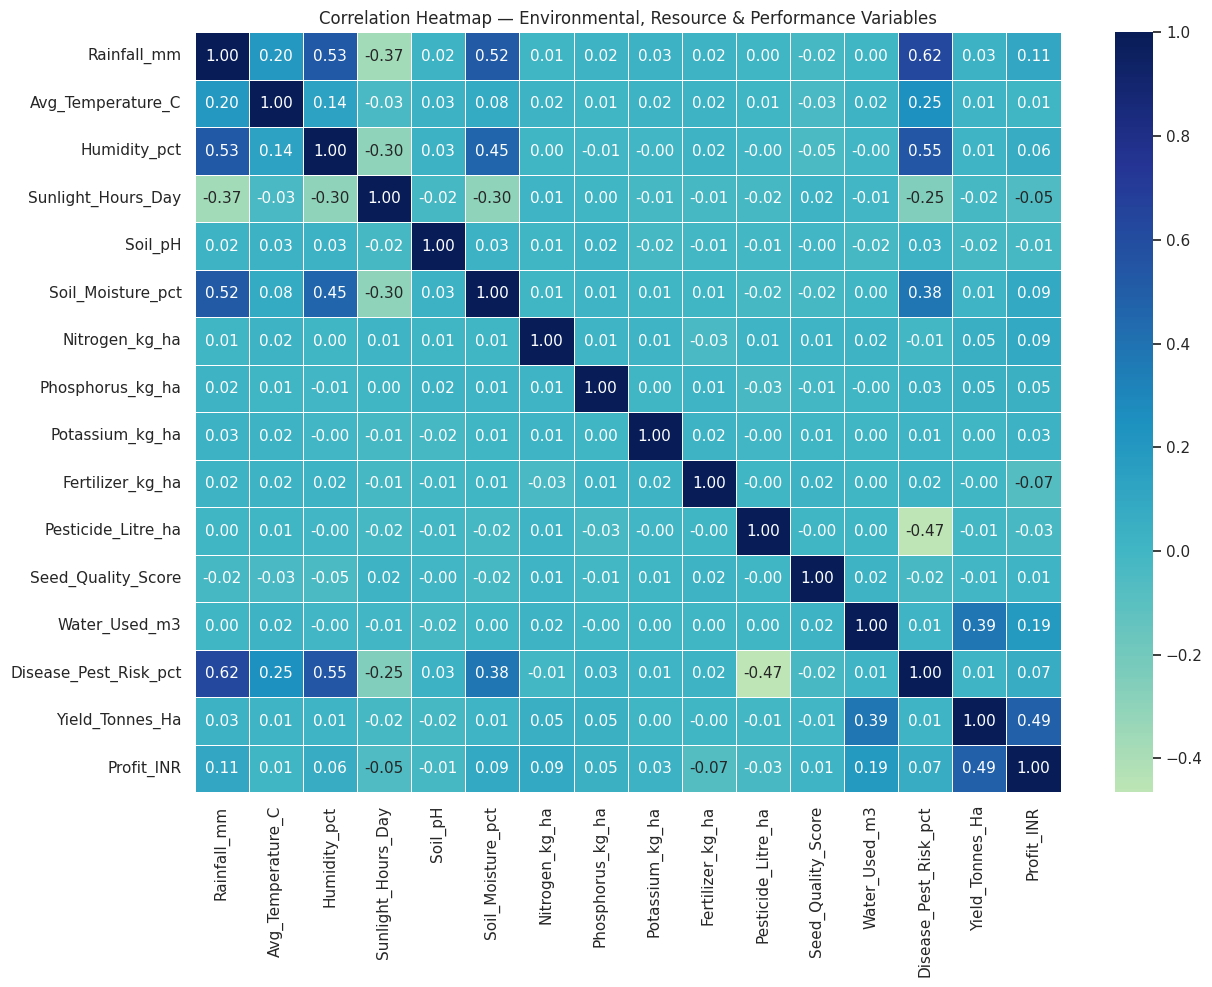

In [79]:
plt.figure(figsize=(13, 10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    center=0,
    linewidths=0.5,
    cmap="YlGnBu"
)

plt.title("Correlation Heatmap — Environmental, Resource & Performance Variables")
plt.tight_layout()
plt.show()


In [67]:
if "Yield_Tonnes_Ha" in corr.columns:
    print("Correlation with Yield_Tonnes_Ha:")
    display(corr["Yield_Tonnes_Ha"].drop("Yield_Tonnes_Ha").sort_values(ascending=False).to_frame("Correlation"))

if "Profit_INR" in corr.columns:
    print("Correlation with Profit_INR:")
    display(corr["Profit_INR"].drop("Profit_INR").sort_values(ascending=False).to_frame("Correlation"))


Correlation with Yield_Tonnes_Ha:


,Correlation
Profit_INR,0.488459
Water_Used_m3,0.386298
Nitrogen_kg_ha,0.053167
Phosphorus_kg_ha,0.047974
Rainfall_mm,0.028836
Disease_Pest_Risk_pct,0.014351
Humidity_pct,0.012337
Soil_Moisture_pct,0.011101
Avg_Temperature_C,0.010026
Potassium_kg_ha,0.003363


Correlation with Profit_INR:


,Correlation
Yield_Tonnes_Ha,0.488459
Water_Used_m3,0.190278
Rainfall_mm,0.106117
Soil_Moisture_pct,0.092436
Nitrogen_kg_ha,0.085016
Disease_Pest_Risk_pct,0.067583
Humidity_pct,0.063775
Phosphorus_kg_ha,0.049747
Potassium_kg_ha,0.031192
Seed_Quality_Score,0.010438


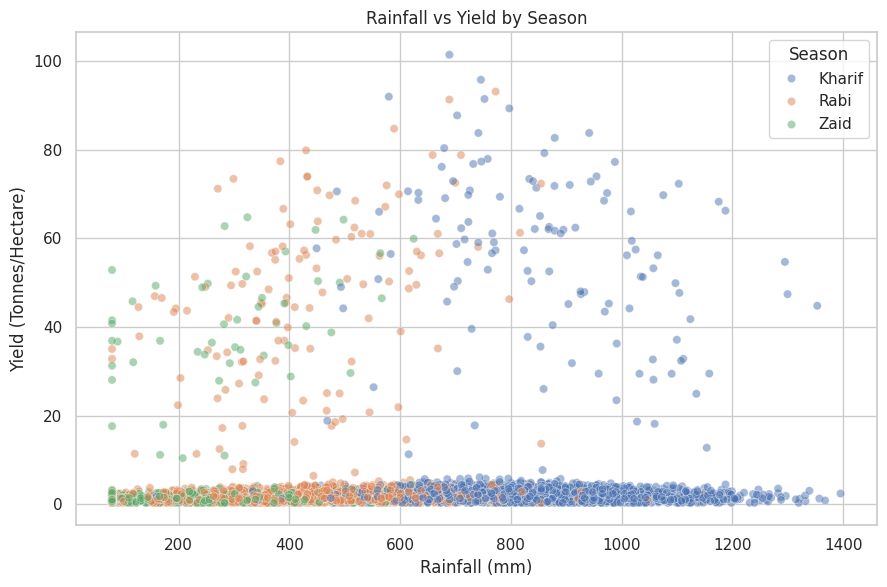

Kharif: Pearson r = -0.019, p = 0.4149
Rabi: Pearson r = 0.041, p = 0.0968
Zaid: Pearson r = 0.047, p = 0.2566


In [68]:
if {"Rainfall_mm", "Yield_Tonnes_Ha", "Season"}.issubset(df.columns):
    plt.figure(figsize=(9, 6))
    sns.scatterplot(
        data=df, x="Rainfall_mm", y="Yield_Tonnes_Ha",
        hue="Season", alpha=0.5
    )
    plt.title("Rainfall vs Yield by Season")
    plt.xlabel("Rainfall (mm)")
    plt.ylabel("Yield (Tonnes/Hectare)")
    plt.tight_layout()
    plt.show()

    for s in season_order:
        subset = df.loc[df["Season"] == s, ["Rainfall_mm", "Yield_Tonnes_Ha"]].dropna()
        if len(subset) >= 3:
            r, p = stats.pearsonr(subset["Rainfall_mm"], subset["Yield_Tonnes_Ha"])
            print(f"{s}: Pearson r = {r:.3f}, p = {p:.4f}")


## 12. Crop Performance Across Seasons

### Q6 — What differences exist between agricultural activities in different seasons?


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.19
Cotton,1.38,1.20,0.96
Groundnut,1.49,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.66
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.28,38.42
Wheat,2.25,2.06,1.75


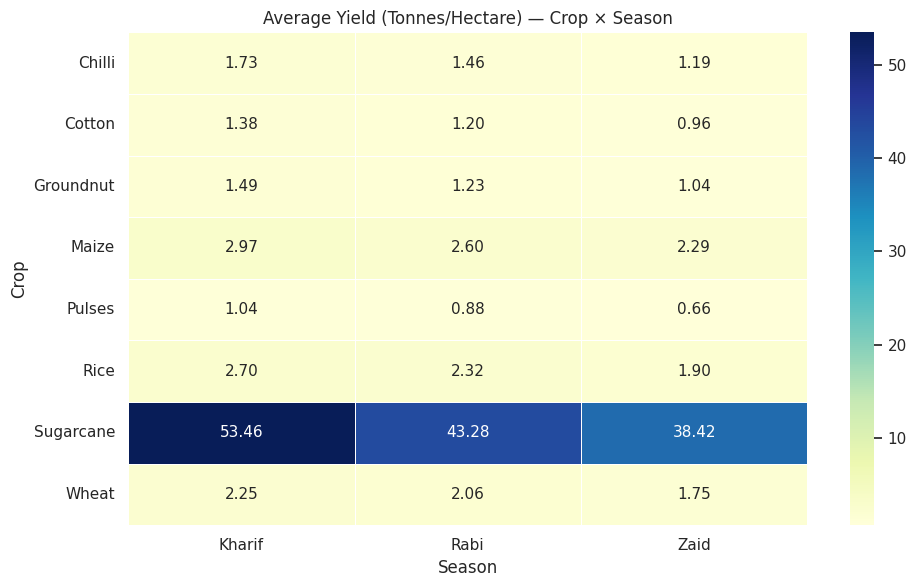

In [82]:
if {"Crop", "Season", "Yield_Tonnes_Ha"}.issubset(df.columns):
    crop_season_yield = df.pivot_table(
        index="Crop", columns="Season", values="Yield_Tonnes_Ha",
        aggfunc="mean", observed=False
    ).reindex(columns=season_order).round(2)

    display(crop_season_yield)

    plt.figure(figsize=(10, 6))
    sns.heatmap(
        crop_season_yield,
        annot=True,
        fmt=".2f",
        linewidths=0.5,
        cmap="YlGnBu"
    )
    plt.title("Average Yield (Tonnes/Hectare) — Crop × Season")
    plt.tight_layout()
    plt.show()

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,954380.0,638572.0,448659.0
Cotton,217000.0,107344.0,-53925.0
Groundnut,108265.0,10417.0,-68872.0
Maize,-39333.0,-89133.0,-194049.0
Pulses,43339.0,-14309.0,-139228.0
Rice,-64903.0,-98428.0,-227239.0
Sugarcane,1000791.0,731613.0,583636.0
Wheat,-105872.0,-119955.0,-193209.0


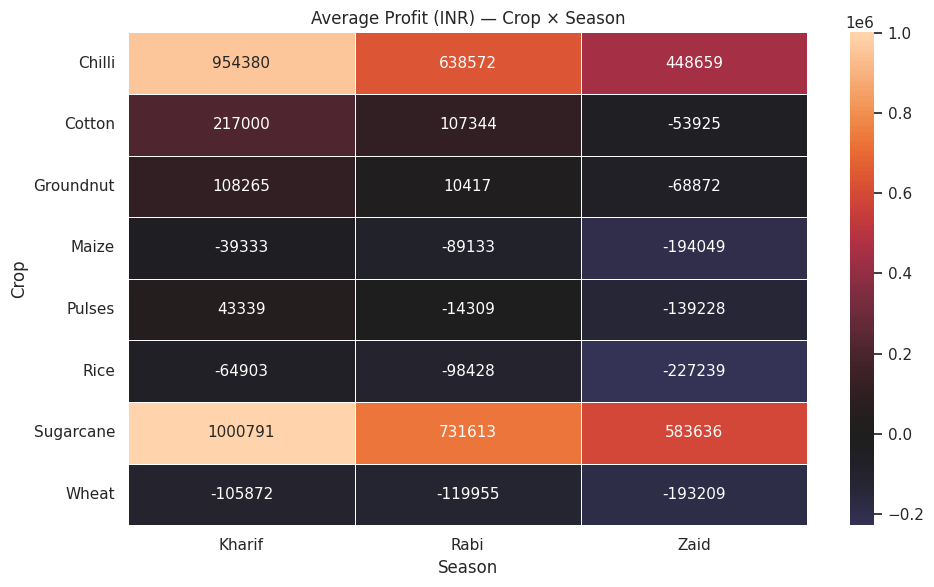

In [70]:
if {"Crop", "Season", "Profit_INR"}.issubset(df.columns):
    crop_season_profit = df.pivot_table(
        index="Crop", columns="Season", values="Profit_INR",
        aggfunc="mean", observed=False
    ).reindex(columns=season_order).round(0)

    display(crop_season_profit)

    plt.figure(figsize=(10, 6))
    sns.heatmap(crop_season_profit, annot=True, fmt=".0f", center=0, linewidths=0.5)
    plt.title("Average Profit (INR) — Crop × Season")
    plt.tight_layout()
    plt.show()


## 13. Regional / State Consistency

### Q7 — Are seasonal patterns consistent across different regions or categories?


Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,5.68,3.47,4.44
Gujarat,6.34,5.44,4.06
Karnataka,6.46,4.57,6.62
Madhya Pradesh,5.99,3.76,5.47
Maharashtra,5.43,5.50,2.27
Punjab,4.10,8.61,5.91
Tamil Nadu,5.52,4.50,4.10
Telangana,5.55,4.78,4.25


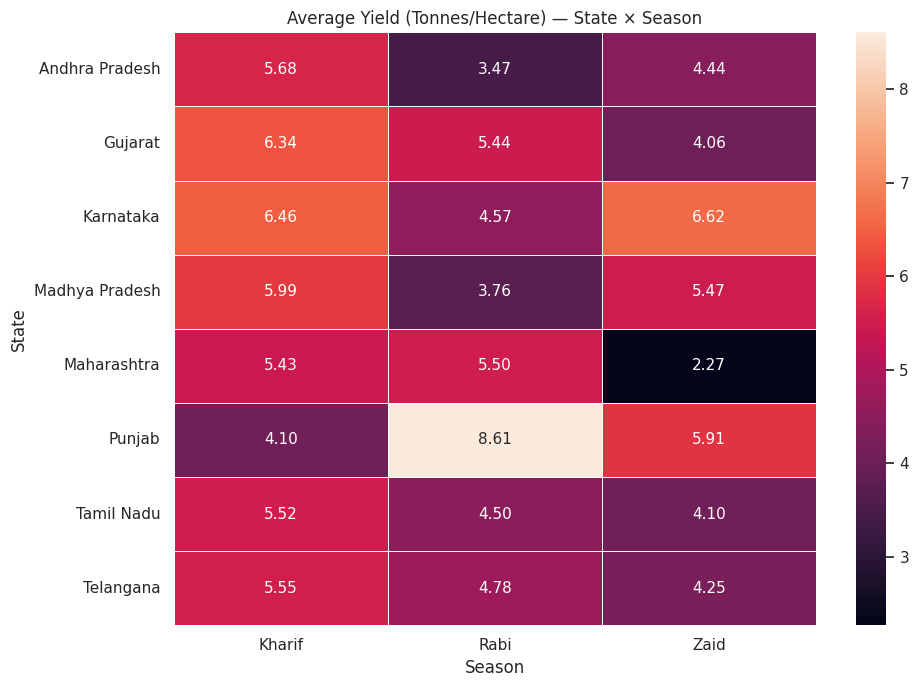

Best-performing season by state:


,Best Season
State,
Andhra Pradesh,Kharif
Gujarat,Kharif
Karnataka,Zaid
Madhya Pradesh,Kharif
Maharashtra,Rabi
Punjab,Rabi
Tamil Nadu,Kharif
Telangana,Kharif


Distribution of best-performing seasons:


,count
Kharif,5
Rabi,2
Zaid,1


In [71]:
if {"State", "Season", "Yield_Tonnes_Ha"}.issubset(df.columns):
    state_season_yield = df.pivot_table(
        index="State", columns="Season", values="Yield_Tonnes_Ha",
        aggfunc="mean", observed=False
    ).reindex(columns=season_order).round(2)

    display(state_season_yield)

    plt.figure(figsize=(10, 7))
    sns.heatmap(state_season_yield, annot=True, fmt=".2f", linewidths=0.5)
    plt.title("Average Yield (Tonnes/Hectare) — State × Season")
    plt.tight_layout()
    plt.show()

    best_season = state_season_yield.idxmax(axis=1)
    print("Best-performing season by state:")
    display(best_season.to_frame("Best Season"))

    print("Distribution of best-performing seasons:")
    display(best_season.value_counts())


## 14. Irrigation Method Within Each Season

### Q8 — How does irrigation method relate to performance within seasons?


Season,Kharif,Rabi,Zaid
Irrigation_Method,,,
Drip,7.26,6.11,5.85
Flood,4.98,5.06,3.98
Rainfed,5.70,3.93,3.06
Sprinkler,4.66,5.31,6.13


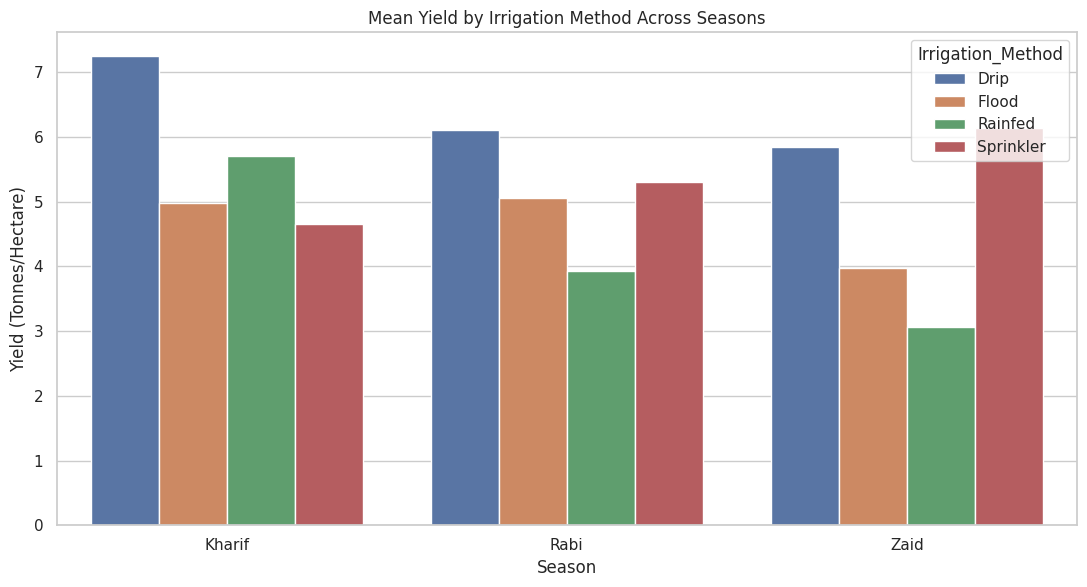

In [72]:
if {"Irrigation_Method", "Season", "Yield_Tonnes_Ha"}.issubset(df.columns):
    irrigation_yield = df.pivot_table(
        index="Irrigation_Method", columns="Season",
        values="Yield_Tonnes_Ha", aggfunc="mean", observed=False
    ).reindex(columns=season_order).round(2)
    display(irrigation_yield)

    plt.figure(figsize=(11, 6))
    sns.barplot(
        data=df, x="Season", y="Yield_Tonnes_Ha",
        hue="Irrigation_Method", order=season_order, errorbar=None
    )
    plt.title("Mean Yield by Irrigation Method Across Seasons")
    plt.ylabel("Yield (Tonnes/Hectare)")
    plt.tight_layout()
    plt.show()


In [73]:
if {"Irrigation_Method", "Season", "Water_Efficiency_t_per_1000m3"}.issubset(df.columns):
    irrigation_eff = df.pivot_table(
        index="Irrigation_Method", columns="Season",
        values="Water_Efficiency_t_per_1000m3", aggfunc="mean", observed=False
    ).reindex(columns=season_order).round(2)
    display(irrigation_eff)


Season,Kharif,Rabi,Zaid
Irrigation_Method,,,
Drip,6.80,6.05,5.30
Flood,3.64,3.48,2.73
Rainfed,8.85,6.87,5.48
Sprinkler,4.62,4.64,4.86


## 15. Unusual or Extreme Seasonal Patterns

### Q9 — Are there unusual or unexpected seasonal patterns?


In [74]:
if "Profit_INR" in df.columns:
    q1, q3 = df["Profit_INR"].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    extreme_loss = df[df["Profit_INR"] < lower_bound].copy()
    extreme_gain = df[df["Profit_INR"] > upper_bound].copy()

    print(f"Extreme-loss observations: {len(extreme_loss)} ({len(extreme_loss)/len(df)*100:.2f}%)")
    print(f"Extreme-gain observations: {len(extreme_gain)} ({len(extreme_gain)/len(df)*100:.2f}%)")

    if len(extreme_loss) and "Season" in df.columns:
        print("\nExtreme losses by season (%):")
        display((extreme_loss["Season"].value_counts(normalize=True) * 100).round(2))

    if len(extreme_gain) and "Season" in df.columns:
        print("\nExtreme gains by season (%):")
        display((extreme_gain["Season"].value_counts(normalize=True) * 100).round(2))


Extreme-loss observations: 51 (1.27%)
Extreme-gain observations: 353 (8.82%)

Extreme losses by season (%):


,proportion
Season,
Kharif,41.18
Rabi,35.29
Zaid,23.53



Extreme gains by season (%):


,proportion
Season,
Kharif,53.82
Rabi,37.39
Zaid,8.78


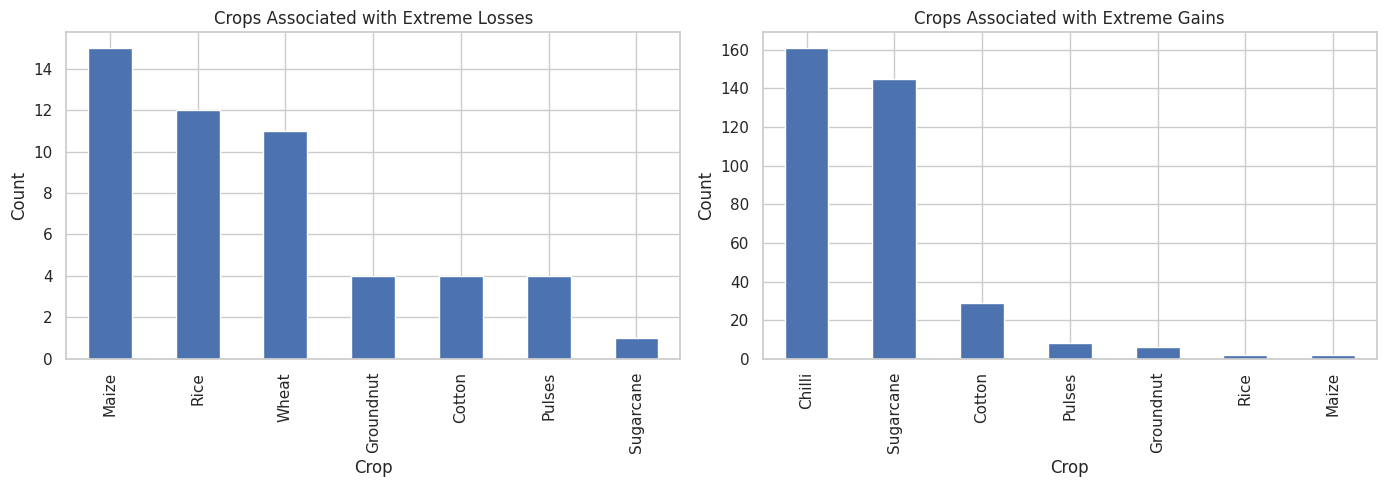

In [75]:
if "Profit_INR" in df.columns and ("Crop" in df.columns):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    if len(extreme_loss):
        extreme_loss["Crop"].value_counts().plot(kind="bar", ax=axes[0])
        axes[0].set_title("Crops Associated with Extreme Losses")
        axes[0].set_ylabel("Count")
    else:
        axes[0].text(0.5, 0.5, "No extreme-loss observations", ha="center", va="center")
        axes[0].set_axis_off()

    if len(extreme_gain):
        extreme_gain["Crop"].value_counts().plot(kind="bar", ax=axes[1])
        axes[1].set_title("Crops Associated with Extreme Gains")
        axes[1].set_ylabel("Count")
    else:
        axes[1].text(0.5, 0.5, "No extreme-gain observations", ha="center", va="center")
        axes[1].set_axis_off()

    plt.tight_layout()
    plt.show()


In [76]:
if "Disease_Pest_Risk_pct" in df.columns and "Profit_INR" in df.columns and len(extreme_loss):
    print("Disease/pest risk comparison:")
    print("Extreme-loss mean risk:", round(extreme_loss["Disease_Pest_Risk_pct"].mean(), 2))
    print("Overall mean risk:     ", round(df["Disease_Pest_Risk_pct"].mean(), 2))

if "Cost_per_Hectare" in df.columns and len(extreme_loss):
    print("\nCost per hectare comparison:")
    print("Extreme-loss mean cost/ha:", round(extreme_loss["Cost_per_Hectare"].mean(), 2))
    print("Overall mean cost/ha:     ", round(df["Cost_per_Hectare"].mean(), 2))


Disease/pest risk comparison:
Extreme-loss mean risk: 45.47
Overall mean risk:      46.37

Cost per hectare comparison:
Extreme-loss mean cost/ha: 75529.25
Overall mean cost/ha:      66660.08


## 16. Statistical Significance Summary

### Q10 — Which seasonal differences are statistically robust?


In [77]:
metrics_to_test = [
    "Yield_Tonnes_Ha", "Profit_INR", "Water_Used_m3",
    "Fertilizer_kg_ha", "Disease_Pest_Risk_pct", "Rainfall_mm"
]

results = []

for metric in metrics_to_test:
    if metric not in df.columns:
        continue

    groups = [
        df.loc[df["Season"] == s, metric].dropna()
        for s in season_order
    ]
    groups = [g for g in groups if len(g) > 0]

    if len(groups) >= 2:
        f, p = stats.f_oneway(*groups)
        results.append({
            "Metric": metric,
            "F-statistic": round(f, 4),
            "p-value": round(p, 6),
            "Significant (p < 0.05)": "Yes" if p < 0.05 else "No"
        })

results_df = pd.DataFrame(results)
display(results_df)


,Metric,F-statistic,p-value,Significant (p < 0.05)
0,Yield_Tonnes_Ha,1.5538,0.211563,No
1,Profit_INR,34.2918,0.000000,Yes
2,Water_Used_m3,2.4665,0.085009,No
3,Fertilizer_kg_ha,0.5143,0.597979,No
4,Disease_Pest_Risk_pct,1049.4674,0.000000,Yes
5,Rainfall_mm,3449.3981,0.000000,Yes


## 17. Key Findings

The findings below are generated from the actual dataset rather than being assumed in advance. This avoids making claims that are not supported by the available observations.

The code summarizes:
- which season has the highest/lowest mean yield,
- which season has the highest/lowest mean profit,
- which environmental variables differ by season,
- which resources differ by season,
- the strongest correlations with yield and profit,
- regional consistency or differences,
- and statistically significant seasonal differences.


In [78]:
# Evidence-based automatic summary
def mean_by_season(column):
    if column not in df.columns:
        return None
    return df.groupby("Season", observed=True)[column].mean().reindex(season_order)

print("=== DATA-DRIVEN KEY FINDINGS ===")

if "Yield_Tonnes_Ha" in df.columns:
    y = mean_by_season("Yield_Tonnes_Ha").dropna()
    print(f"1. Highest mean yield: {y.idxmax()} ({y.max():.2f} tonnes/ha)")
    print(f"   Lowest mean yield:  {y.idxmin()} ({y.min():.2f} tonnes/ha)")

if "Profit_INR" in df.columns:
    p = mean_by_season("Profit_INR").dropna()
    print(f"2. Highest mean profit: {p.idxmax()} (INR {p.max():,.2f})")
    print(f"   Lowest mean profit:  {p.idxmin()} (INR {p.min():,.2f})")

if "Is_Profitable" in df.columns:
    pp = df.groupby("Season", observed=True)["Is_Profitable"].mean().reindex(season_order).dropna() * 100
    print(f"3. Highest share of profitable farms: {pp.idxmax()} ({pp.max():.1f}%)")

if "Rainfall_mm" in df.columns:
    r = mean_by_season("Rainfall_mm").dropna()
    print(f"4. Highest mean rainfall: {r.idxmax()} ({r.max():.2f} mm)")
    print(f"   Lowest mean rainfall:  {r.idxmin()} ({r.min():.2f} mm)")

if "Water_Used_m3" in df.columns:
    w = mean_by_season("Water_Used_m3").dropna()
    print(f"5. Highest mean water use: {w.idxmax()} ({w.max():.2f} m³)")

print("\nThese observations should be interpreted together with the statistical tests and visualizations above.")


=== DATA-DRIVEN KEY FINDINGS ===
1. Highest mean yield: Kharif (5.63 tonnes/ha)
   Lowest mean yield:  Zaid (4.64 tonnes/ha)
2. Highest mean profit: Kharif (INR 178,914.65)
   Lowest mean profit:  Zaid (INR -24,804.82)
3. Highest share of profitable farms: Kharif (57.8%)
4. Highest mean rainfall: Kharif (852.11 mm)
   Lowest mean rainfall:  Zaid (299.12 mm)
5. Highest mean water use: Zaid (6419.89 m³)

These observations should be interpreted together with the statistical tests and visualizations above.


## 18. Conclusions and Evidence-Based Recommendations

### Conclusions

The project conclusions should be based on the results generated above. In particular:

- Seasonal differences should be described only where the dataset shows meaningful differences.
- Statistical significance should be determined using the reported p-values rather than assumed.
- Environmental conditions, resource usage, crop performance, regional variation and economic outcomes should be interpreted together.
- Unusual observations should be investigated rather than automatically treated as errors.

### Recommendations

Recommendations should follow directly from the observed evidence. Depending on the results, appropriate recommendations may include:

1. Improve seasonal resource planning where water, fertilizer or other inputs show substantial variation.
2. Consider crop-season combinations with comparatively stronger yield or economic performance.
3. Promote efficient irrigation practices where water use and water efficiency indicate a clear opportunity.
4. Give additional attention to seasons, regions or crop groups associated with unusual losses or lower performance.
5. Use environmental and economic indicators together when planning seasonal agricultural activities.
6. Continue collecting consistent seasonal data so that future analyses can validate these patterns.

**Important:** Recommendations must be refined after running the notebook on the supplied dataset; the notebook deliberately avoids presenting unsupported fixed conclusions.


## 19. Final Project Checklist

- [x] Dataset exploration
- [x] Data cleaning and preparation
- [x] Missing-value treatment
- [x] Duplicate and sanity checks
- [x] Feature engineering
- [x] Seasonal comparison
- [x] Environmental analysis
- [x] Resource-usage analysis
- [x] Economic analysis
- [x] Crop and regional comparison
- [x] Correlation analysis
- [x] Statistical significance testing
- [x] Outlier/extreme-pattern analysis
- [x] Evidence-based findings
- [x] Conclusions and recommendations

This structure follows the Major Project brief: Seasonal Agriculture Performance Analysis.
